In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

# dict with all my dag scans
from scan_dict import scan_dir_dict

In [8]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/debug_minimizer/study_interpolation"
os.system(f"mkdir -p {plotting_path}")

0

In [56]:
# load the data
drop_unsuccessful = False
scan_dict = {}
data = {}
# for name, scan_dir in scan_dir_dict.items():
for name in ["globalfit_double_hese_SPL","globalfit_double_hese_BPL", "globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB"]:
    scan_dir = scan_dir_dict[name]
    print(name)
    print(scan_dir)
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    if "3flavor" in name or "gf" in name:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_angle(scan_dict,name)
    else:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid = 30)

globalfit_double_hese_SPL
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/globalfit_double_hese_SPL
removed stuff
globalfit_double_hese_BPL
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/globalfit_double_hese_BPL
removed stuff
globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit/debug_minimizer/globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB
removed stuff


/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_hese_SPL / globalfit_double_hese_SPL) at 68%: 1.0000
Area ratio (globalfit_double_hese_BPL / globalfit_double_hese_SPL) at 68%: 5.1758
Area ratio (globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB / globalfit_double_hese_SPL) at 68%: 1.5662


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:133: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:133: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:133: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:133: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

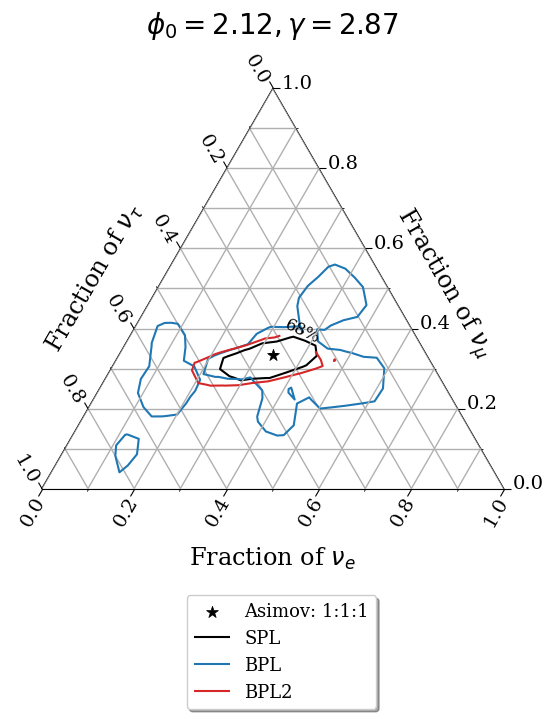

In [13]:
# spice_ftp_oldpid_bdtprod
names = [
"globalfit_double_hese_SPL",
"globalfit_double_hese_BPL",
"globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB",
]
labels = [
    "SPL",
    "BPL",
    "BPL2",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/globalfit_double_hese.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_hese_SPL", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


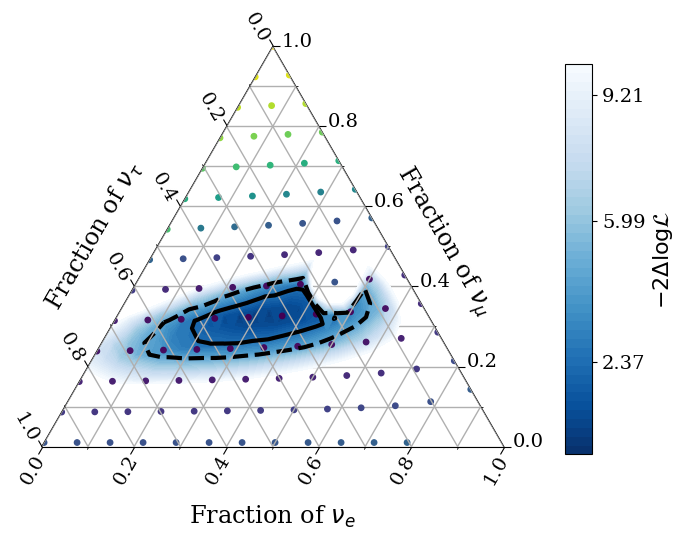

In [24]:
likelihood_contour(data = data,
                  name = "globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB",
                  levels = ["68%","90%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB_lik.png")

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


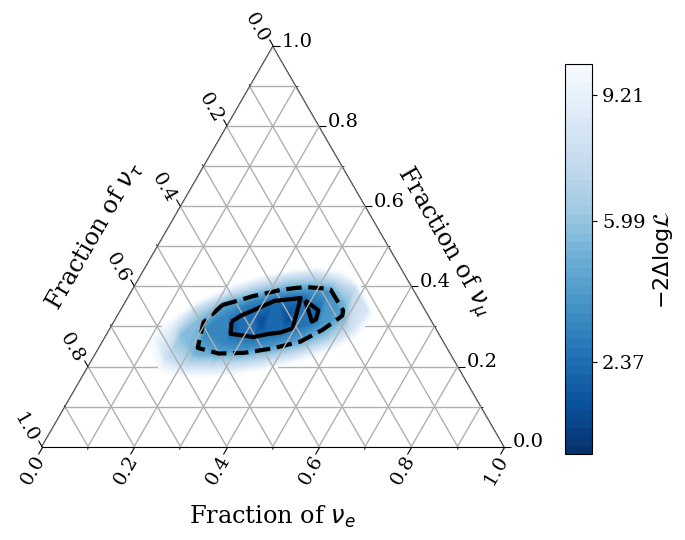

In [7]:
likelihood_contour(data = data,
                  name = "globalfit_double_hese_SPL",
                  levels = ["68%","90%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/globalfit_double_hese_lik.png")

In [74]:
name = "globalfit_double_no_hybrid_muon_BPL_range_philipp_strict_LBFGSB"
df = scan_dict[name].get_scan_df("astro_nue_ratio-astro_nutau_ratio").copy()
df["fe"] = df["astro_nue_ratio"]/(1+ df["astro_nue_ratio"] + df["astro_nutau_ratio"])
df["fmu"] = 1/(1+ df["astro_nue_ratio"] + df["astro_nutau_ratio"])
df["ftau"] = df["astro_nutau_ratio"]/(1+ df["astro_nue_ratio"] + df["astro_nutau_ratio"])

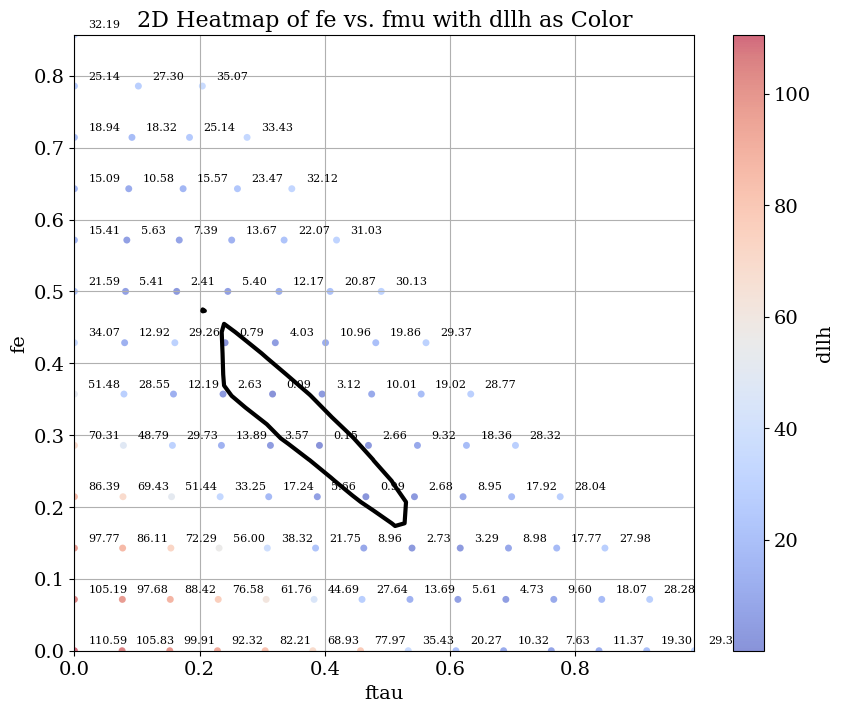

In [86]:
from scipy.interpolate import interp2d

# Create a 2D histogram for the heatmap
heatmap, xedges, yedges = np.histogram2d(df["fe"], df["fmu"], bins=50, range=[[0, 1], [0, 1]])

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    df["ftau"],
    df["fe"],
    c=df["dllh"],
    cmap="coolwarm",
    alpha=0.6,
    edgecolors="none",
    s=25,
)
ts_dict = {
    '68%' : 2.37,
    '90%' : 4.605,
    '95%' : 5.99,
}

levels = ['68%']
ts_values = [ts_dict[i] for i in levels]

C2 = ax.contour(data[name]["ftau_grid"],
                data[name]["fe_grid"],
                    data[name]["ts_grid"],  
                    ts_values,
                    linestyles=["-",'--'],
                    linewidths=3,
                    colors='black')

# Annotate each point with its dllh value
for i, row in df.iterrows():
    ax.annotate(
        f"{row['dllh']:.2f}",  # Format dllh to 2 decimal places
        (row["ftau"], row["fe"]),
        fontsize=8,
        textcoords="offset points",
        xytext=(10, 5),  # Offset the text slightly from the point
        ha='left'
    )

fig.colorbar(sc, ax=ax, label="dllh")

# Add labels and title
ax.set_title("2D Heatmap of fe vs. fmu with dllh as Color")
ax.set_xlabel("ftau")
ax.set_ylabel("fe")
ax.grid(True)

plt.show()

In [85]:
mask = (df["fe"] > 0.4) & (df["fe"] < 0.5) & (df["ftau"] > 0.1) & (df["ftau"] < 0.2)
# mask = df["fe"] >= 0.
df["dllh-llh"] =  df["llh"] - df["dllh"]/2
df[mask][["fe","ftau","fmu","llh","dllh","dllh-llh","fit_success"]]
df[mask].iloc[0]


CR_grad               0.119945
astro_norm             2.04303
astro_nue_ratio       1.042701
astro_nutau_ratio     0.390268
barr_h               -0.011476
barr_w                0.282672
barr_y                -0.11791
barr_z               -0.099674
conv_norm             1.070931
delta_gamma          -0.043775
e_break                    3.5
effective_veto        0.814133
fit_success                1.0
gamma_1                    3.0
gamma_2               2.582893
llh                  14.632108
muon_norm             1.001877
muongun_norm          0.994445
prompt_norm                0.0
dllh                 29.264216
fe                    0.428571
fmu                    0.41102
ftau                  0.160408
dllh-llh                   0.0
Name: 58, dtype: Float64

In [68]:
# Assuming data[name] contains the grids
fe_grid = data[name]["fe_grid"]
ftau_grid = data[name]["ftau_grid"]
ts_grid = data[name]["ts_grid"]

# Repeat fe and ftau to match the length of the flattened TS_gridded
fe_repeated = np.repeat(fe_grid, len(ftau_grid))
ftau_tiled = np.tile(ftau_grid, len(fe_grid))

# Flatten TS_gridded
ts_flattened = ts_grid.ravel()

# Create DataFrame
df = pd.DataFrame({
    'fe': fe_repeated,
    'ftau': ftau_tiled,
    'fmu': 1-fe_repeated-ftau_tiled,
    'ts': ts_flattened
})

In [72]:

mask = (df["fe"] > 0.4) & (df["fe"] < 0.5) & (df["fmu"] > 0.4) & (df["fmu"] < 0.5)
df[mask][["fe","fmu","ts"]]

,fe,fmu,ts
423,0.413793,0.483793,14.007754
424,0.413793,0.449655,20.963405
425,0.413793,0.415517,24.434665
452,0.443350,0.488374,13.791912
453,0.443350,0.454236,15.832011
454,0.443350,0.420099,22.787662
481,0.472906,0.492956,17.567938
482,0.472906,0.458818,10.803601
483,0.472906,0.424680,12.600468
